# Autoemcoder (amomaly detector)

In [2]:
import os
os.chdir('..')

In [371]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, LeakyReLU, BatchNormalization, Lambda, Concatenate
from tensorflow.keras.models import Model,load_model
from tensorflow.keras import optimizers
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing import image
from tensorflow.keras.losses import binary_crossentropy

from sklearn.preprocessing import LabelEncoder

In [4]:
import zipfile

with zipfile.ZipFile("data/faces.zip", 'r') as zip_ref:
    zip_ref.extractall("data/faces")

In [5]:
path_smile="data/labels/SMILE_list.txt"
path_nonSmile="data/labels/NON-SMILE_list.txt"

try:
    with open(path_smile, 'r') as f:
        files_smile = []
        for line in f:
            line.strip()
            line=line[:-4]+"ppm"
            files_smile.append(line)
except FileNotFoundError:
    print(f"Error: The file '{path_smile}' was not found.")

try:
    with open(path_nonSmile, 'r') as f:
        files_nonSmile = []
        for line in f:
            line.strip()
            line=line[:-4]+"ppm"
            files_nonSmile.append(line)
except FileNotFoundError:
    print(f"Error: The file '{path_nonSmile}' was not found.")

In [6]:
rootpath = "data/faces/" 

n = 600 
target_size = (200,200) 

imgs_smile = [] 
imgs_nonSmile = [] 

for i in range(n):
    img2 = image.load_img(rootpath + files_smile[i], target_size=target_size)
    img2 = image.img_to_array(img2)
    img2 = img2/255.
    imgs_smile.append(img2)

    img = image.load_img(rootpath + files_nonSmile[i], target_size=target_size)
    img = image.img_to_array(img)
    img = img/255.
    imgs_nonSmile.append(img)

imgs_smile=np.array(imgs_smile)
imgs_nonSmile=np.array(imgs_nonSmile)

# shuffle images
np.random.seed(123)
idxs = np.random.choice(n, size=n, replace=False)
imgs_smile = imgs_smile[idxs,:,:,:]
imgs_nonSmile = imgs_nonSmile[idxs,:,:,:]

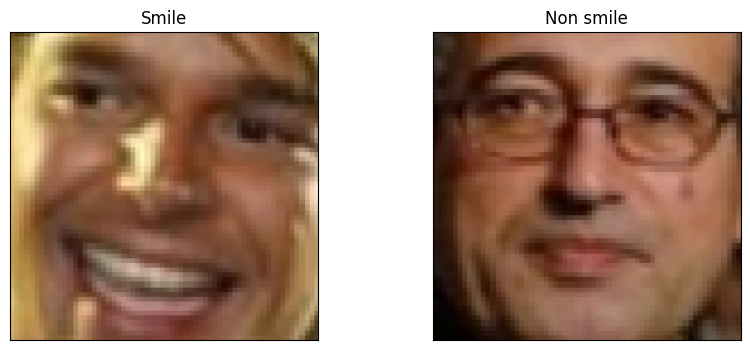

In [7]:
selected = 10
plt.figure(figsize=(10, 4))

ax = plt.subplot(1, 2, 1)
plt.imshow(imgs_smile[selected,])
ax.set_title('Smile')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

ax = plt.subplot(1, 2, 2)
plt.imshow(imgs_nonSmile[selected,])
ax.set_title('Non smile')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

plt.show()

In [8]:
test_split=0.2
n_test = int(n*test_split)

train_smile = imgs_smile[n_test:,:,:,:]
train_nonSmile = imgs_nonSmile[n_test:,:,:,:]

# This is the test set.
test_smile = imgs_smile[0:n_test,:,:,:]
test_nonSmile = imgs_nonSmile[0:n_test,:,:,:]

test_features=np.concatenate((test_smile, test_nonSmile), axis=0)
test_labels=np.concatenate((np.full(n_test, "smile"), np.full(n_test, "non-smile")))

idxs = np.random.choice(n_test*2, size=n_test*2, replace=False)
test_features = test_features[idxs,:,:,:]
test_labels = test_labels[idxs]

In [9]:
le = LabelEncoder()
test_labels_int = le.fit_transform(test_labels) #smile=1, non-smile=0

In [10]:
print(test_labels[0])
print(test_labels_int[0])

smile
1


In [11]:
train_nonSmile.shape

(480, 200, 200, 3)

In [527]:

def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

def combined_loss(y_true, y_pred):
    bce = binary_crossentropy(y_true, y_pred)
    #l1  = tf.reduce_mean(tf.abs(y_true - y_pred))
    #s   = ssim_loss(y_true, y_pred)
    brightness = tf.reduce_mean(y_true, axis=-1, keepdims=True)
    weighted=brightness**2
    weighted_error = tf.abs(y_true - y_pred) * (1 + 2 * weighted)
    l1 = tf.reduce_mean(weighted_error)
    return 0.0*bce + 1.0*l1
    #return loss

def add_sobel_channels(x):
    edges = tf.image.sobel_edges(x)   # (B, 200, 200, 2, 3)
    shape = tf.shape(edges)
    # flatten last two dims: 2*3 = 6 channels
    edges = tf.reshape(edges, (shape[0], shape[1], shape[2], 6))
    return edges

input_img = Input(shape=(200, 200, 3))

edges = Lambda(add_sobel_channels)(input_img)
x = Concatenate(axis=-1)([input_img, edges])

x = Conv2D(9, 7, strides=2, padding='same')(x)
x = LeakyReLU()(x)
x = Conv2D(16, 5, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Conv2D(32, 3, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Conv2D(64, 3, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Conv2D(128, 3, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

encoded = Conv2D(128, 3, strides=2, padding='same')(x)
encoded = LeakyReLU(name="encoded")(encoded)

x = Conv2D(128, (3, 3), activation='leaky_relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='leaky_relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='leaky_relu')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='leaky_relu')(x) 
x = UpSampling2D((2, 2))(x)
x = Conv2D(8, (3, 3), activation='leaky_relu', padding='same')(x) 
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(3, 3, activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer=optimizers.Adam(),#1e-3
                    loss=combined_loss,
                    metrics=["mae", "mse"])

autoencoder.summary()

Model: "functional_39"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_42      │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_12 (Lambda)  │ (None, 200, 200,  │          0 │ input_layer_42[0… │
│                     │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 200, 200,  │          0 │ input_layer_42[0… │
│ (Concatenate)       │ 9)                │            │ lambda_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_384 (Conv2D) │ (None, 100, 100,  │      3,978 │ concatenate_12[0… │
│                     │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_176     │ (None, 100, 100,  │          0 │ conv2d_384[0][0]  │
│ (LeakyReLU)         │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_385 (Conv2D) │ (None, 50, 50,    │      3,616 │ leaky_re_lu_176[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 50,    │         64 │ conv2d_385[0][0]  │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_177     │ (None, 50, 50,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_386 (Conv2D) │ (None, 25, 25,    │      4,640 │ leaky_re_lu_177[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 25,    │        128 │ conv2d_386[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_178     │ (None, 25, 25,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_387 (Conv2D) │ (None, 13, 13,    │     18,496 │ leaky_re_lu_178[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │        256 │ conv2d_387[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_179     │ (None, 13, 13,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_388 (Conv2D) │ (None, 7, 7, 128) │     73,856 │ leaky_re_lu_179[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ conv2d_388[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_180     │ (None, 7, 7, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                 

 Total params: 351,389 (1.34 MB)

 Trainable params: 350,909 (1.34 MB)

 Non-trainable params: 480 (1.88 KB)

In [528]:
history = autoencoder.fit(train_nonSmile, train_nonSmile,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.15)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 512ms/step - loss: 0.1728 - mae: 0.1146 - mse: 0.0235 - val_loss: 0.2287 - val_mae: 0.1550 - val_mse: 0.0366
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 424ms/step - loss: 0.1123 - mae: 0.0749 - mse: 0.0102 - val_loss: 0.2059 - val_mae: 0.1453 - val_mse: 0.0337
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 407ms/step - loss: 0.1021 - mae: 0.0679 - mse: 0.0086 - val_loss: 0.2115 - val_mae: 0.1537 - val_mse: 0.0374
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 413ms/step - loss: 0.0973 - mae: 0.0644 - mse: 0.0078 - val_loss: 0.1913 - val_mae: 0.1358 - val_mse: 0.0296
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 411ms/step - loss: 0.0962 - mae: 0.0643 - mse: 0.0075 - val_loss: 0.1909 - val_mae: 0.1376 - val_mse: 0.0305
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 437ms/step - loss: 0.0897 - mae: 0.0593 - mse: 0.0065 - val_loss: 0.1976 - val_mae: 0.1448 - val_mse: 0.0331
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 442ms/step - loss: 0.0854 - mae: 0.0572 - mse: 0.0

In [569]:
autoencoder.save("model/autoencoder.keras")
#autoencoder = load_model("model/autoencoder1.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


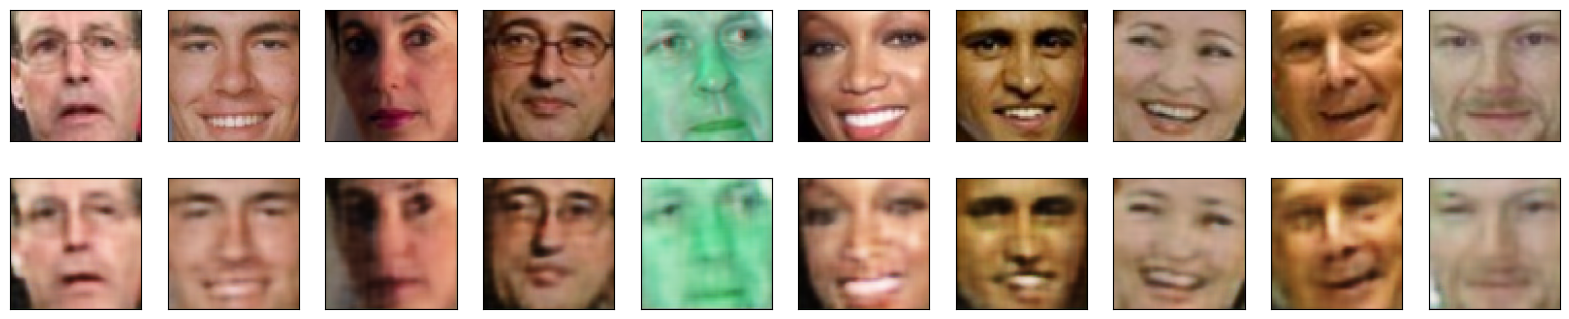

In [529]:
m = 10

decoded_imgs = autoencoder.predict(test_features[1:m+1,])

plt.figure(figsize=(20, 4))
for i in range(m):
    # display original
    ax = plt.subplot(2, m, i + 1)
    plt.imshow(test_features[i+1].reshape(test_features.shape[1], test_features.shape[2], test_features.shape[3]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, m, i + 1 + m)
    plt.imshow(decoded_imgs[i].reshape(test_features.shape[1], test_features.shape[2], test_features.shape[3]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


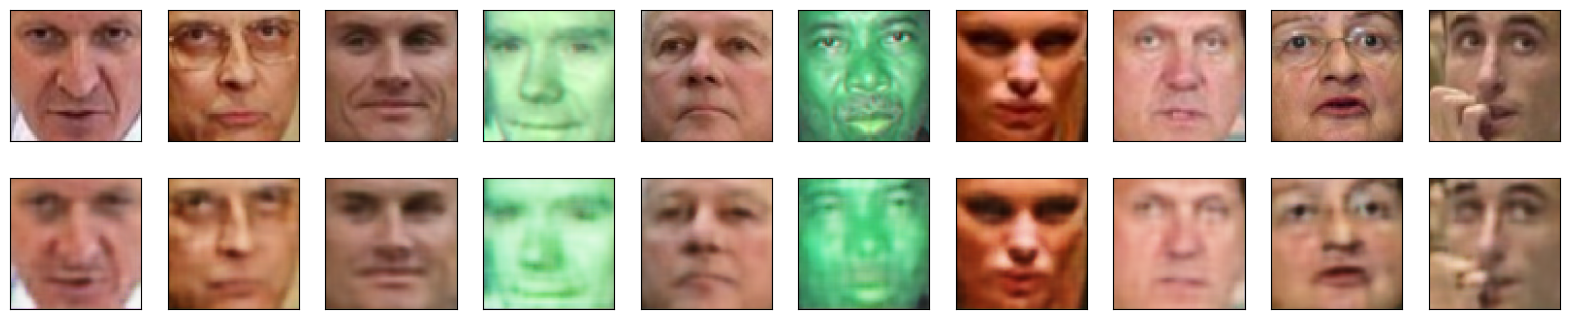

In [530]:
m = 10

decoded_imgs = autoencoder.predict(train_nonSmile[1:m+1,])

plt.figure(figsize=(20, 4))
for i in range(m):
    # display original
    ax = plt.subplot(2, m, i + 1)
    plt.imshow(train_nonSmile[i+1].reshape(train_nonSmile.shape[1], train_nonSmile.shape[2], train_nonSmile.shape[3]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, m, i + 1 + m)
    plt.imshow(decoded_imgs[i].reshape(train_nonSmile.shape[1], train_nonSmile.shape[2], train_nonSmile.shape[3]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

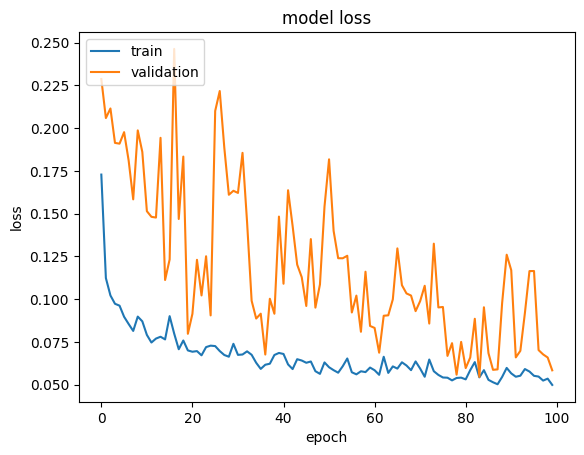

In [531]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [532]:
# Evaluate the model on the train set and print the loss.
autoencoder.evaluate(train_nonSmile, train_nonSmile) # [loss]

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - loss: 0.0548 - mae: 0.0373 - mse: 0.0024


[0.05477643385529518, 0.03728078305721283, 0.002393669681623578]

In [533]:
autoencoder.evaluate(test_nonSmile, test_nonSmile)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - loss: 0.0576 - mae: 0.0391 - mse: 0.0027


[0.05762241780757904, 0.0391196683049202, 0.0026642396114766598]

In [105]:
# Define function to compute squared errors (reconstruction errors).
def bce_tensor(predictions, gt):
  bce = binary_crossentropy(gt, predictions)
  bce_per_image = tf.reduce_mean(bce, axis=[1,2])
  return bce_per_image.numpy()

In [182]:
def ssim_loss(y_true, y_pred):
    # SSIM produces value in [-1,1] or [0,1] depending on implementation, use tf.image.ssim with max_val=1
    return 1.0 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

In [534]:
def combined_loss(y_true, y_pred):
    # BCE + L1 + SSIM
    bce = tf.reduce_mean(binary_crossentropy(y_true, y_pred), axis=[1,2])
    #l1 = tf.reduce_mean(tf.abs(y_true - y_pred) * mouth_mask, axis=[1,2,3])
    #s = ssim_loss(y_true, y_pred)
    #return (.5 * b + 0.3 * l1 + 0.2 * s).numpy()
    brightness = tf.reduce_mean(y_true, axis=-1, keepdims=True)
    weighted_error = tf.abs(y_true - y_pred) * (1 + 2 * brightness)
    l1 = tf.reduce_mean(weighted_error, axis=[1,2,3])
    return (0.0*bce + 1.0*l1).numpy()

In [535]:
# Make predictions on the train set.
predictions = autoencoder.predict(train_nonSmile)
train_nonSmile_errors = combined_loss(train_nonSmile,predictions)
threshold = train_nonSmile_errors.mean() + 1 * train_nonSmile_errors.std()
print(threshold)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step
0.08141698


In [536]:
print(np.mean(train_nonSmile_errors))

quantiles = np.quantile(train_nonSmile_errors, [0.0, 0.25, 0.50, 0.75, .90, 1.0])
print(quantiles)

0.07106792
[0.04359936 0.06438084 0.06918062 0.07598643 0.08438789 0.12395544]


In [562]:
threshold = 0.075
test_predictions = autoencoder.predict(test_features)
test_errors = combined_loss(test_features,test_predictions)
test_labels_predictions = np.where(np.array(test_errors) > threshold, 1, 0)

print(test_errors[0:10])
print(test_labels_predictions[0:10])

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
[0.07762254 0.07850979 0.07558626 0.06382914 0.07402099 0.10560969
 0.08267871 0.07851361 0.06548669 0.07220429]
[1 1 1 0 0 1 1 1 0 0]


In [564]:
predictions_str = le.inverse_transform(test_labels_predictions)

In [565]:
pd.crosstab(test_labels, predictions_str, rownames=['True labels'], colnames=['Predicted labels'])

Predicted labels,non-smile,smile
True labels,,
non-smile,74,46
smile,43,77
